## Студенческий проект: анализ ассортимента методом ABC/XYZ


Автор: Луцкова Екатерина

Дата: 07.10.2026

## Цели и задачи проекта

<b>Цель проекта:</b> оценить структуру ассортимента британского интернет-магазина подарков и товаров для дома и предложить правила управления товарными позициями.

<b>Задачи проекта:</b>

* загрузить данные и проверить их на корректность;
* проанализировать базовую картину бизнеса за исследуемый период;
* провести анализ ассортимента методом ABC/XYZ;
* интепретировать результаты и сформировать список товаров на вывод из ассортимента.

## Описание данных

Датасет `Online Retail II` содержит в себе информацию о транзакционных данных интернет-магазина в период с 2009 по 2011 гг. 

Таблица имеет следующие поля:

* Invoice — Номер счета / заказа. Используется для подсчета заказов и выявления отмен.
* StockCode — Код товарной позиции (SKU). 
* Description — Описание / название товара.
* Quantity — Количество единиц товара в операции.
* InvoiceDate — Дата и время операции. 
* Price — Цена одной единицы товара.
* Customer ID — Идентификатор покупателя.
* Country — Страна клиента. 

## Содержимое проекта

1. [Загрузка данных и знакомство с ними](#Загрузка-данных-и-знакомство-с-ними)
2. [Базовая картина бизнеса](#Базовая-картина-бизнеса)
3. [ABC-анализ](#ABC-анализ)
4. [XYZ-анализ](#XYZ-анализ)
5. [Объединенная матрица ABC/XYZ](#Объединенная-матрица-ABC/XYZ)
6. [Интерпретация и стратегия управления](#Интерпретация-и-стратегия-управления)
7. [Формируем список кандидатов на сокращение](#Формируем-список-кандидатов-на-сокращение)

## Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Загрузим первый датасет с данными за 2009-2010 гг.

In [2]:
sales_1 = pd.read_csv("C:/Users/eklut/OneDrive/Рабочий стол/Я.практикум/Аналитика данных/Анализ ассортимента методом ABC XYZ/Data.csv")

Проверим, что данные загрузились и выглядят корректно.

In [3]:
sales_1.head(15)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,"1,25",13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,12/1/09 7:45,"1,65",13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,12/1/09 7:45,"1,25",13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,12/1/09 7:45,"5,95",13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,12/1/09 7:46,"2,55",13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,12/1/09 7:46,"3,75",13085.0,United Kingdom


Посмотрим на количество строк и типы данных в столбцах.

In [4]:
sales_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  object 
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 32.1+ MB


Видим, что в датафрейме 8 столбцов и 525461 строк. Пропуски содержатся только в столбцах `Description` и `Customer ID`.
В остальных столбцах пропусков нет.

Что касается типов данных, то в столбце `InvoiceDate` тип задан неверно (object), необходимо будет привести данные к типу datetime. Столбец `Price` также представлен типом данных object вместо float64. Для столбца `Customer ID` оптимальным будет тип object , т.к. столбец хранит информацию об ID покупателя. 

Во всех остальных столбцах тип данных определен верно.

Загрузим второй датасет с данными за 2010-2011 гг.

In [5]:
sales_2 = pd.read_csv("C:/Users/eklut/OneDrive/Рабочий стол/Я.практикум/Аналитика данных/Анализ ассортимента методом ABC XYZ/online_retail_II.xlsx - Year 2010-2011.csv")

Проверим, что данные загрузились и выглядят корректно.

In [6]:
sales_2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,"3,39",17850.0,United Kingdom


Посмотрим на количество строк и типы данных в столбцах.

In [7]:
sales_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  object 
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


В этом датафрейме также 8 столбцов и 541910 строк. 
Что касается пропусков, то они содержатся в тех же столбцах - `Description` и `Customer ID`.
Ситуация с типами данных такая же, как и в первом датафрейме.

Поскольку количество столбцов в двух датафреймах одинаковое, они содержат индентичную информацию, мы можем объединить датафреймы в один.
Но прежде необходимо исключить пересечения в столбце с датами покупки.

In [8]:
sales_1['InvoiceDate']=sales_1['InvoiceDate'].astype('datetime64[ns]')
sales_2['InvoiceDate']=sales_2['InvoiceDate'].astype('datetime64[ns]')

# Находим даты, которые есть в sales_1
dates_in_sales_1 = set(sales_1['InvoiceDate'].dropna().unique())

# Из sales_2 убираем строки, которые встречается в sales_1
sales_2_clean = sales_2[~sales_2['InvoiceDate'].isin(dates_in_sales_1)]

# Объединяем
sales = pd.concat([sales_1, sales_2_clean], ignore_index=True)

Проверяем, что объединение прошло успешно.

In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044848 entries, 0 to 1044847
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1044848 non-null  object        
 1   StockCode    1044848 non-null  object        
 2   Description  1040573 non-null  object        
 3   Quantity     1044848 non-null  int64         
 4   InvoiceDate  1044848 non-null  datetime64[ns]
 5   Price        1044848 non-null  object        
 6   Customer ID  809561 non-null   float64       
 7   Country      1044848 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 63.8+ MB


В новом датафрейме поменяем типы данных на более подходящие.

In [10]:
sales['Price'] = sales['Price'].str.replace(',', '.').astype('float64')

In [11]:
sales['Customer ID'] = sales['Customer ID'].astype('object')

Название столбца `Customer ID` следует привести к стандартному написанию (без пробелов). 

In [12]:
sales = sales.rename(columns={'Customer ID': 'CustomerID'})

<b>Поиск пропусков</b>

Узнаем, каков процент пропусков в получившемся датафрейме, и решим, как поступить с ними дальше.

In [13]:
missing_share = sales.isna().mean()
print(missing_share)

Invoice        0.000000
StockCode      0.000000
Description    0.004092
Quantity       0.000000
InvoiceDate    0.000000
Price          0.000000
CustomerID     0.225188
Country        0.000000
dtype: float64


В столбце `Description` содержится менее 1% пропусков, что не является критическим значением. В столбце `Customer ID` более 22% пропущенных значений, однако для дальнейшего анализа номера покупателей нам не потребуются. Тем более заменить их на что-то другое, кроме как на достоверные значения, мы не можем.

Оставим все пропуски без изменений.

<b>Поиск дубликатов</b>

In [14]:
sales.duplicated().sum()

11812

Обнаружено 11812 явных дубликатов. Для дальнейшей работы удалим их.

In [15]:
sales = sales.drop_duplicates()

Теперь проверим датафрейм на скрытые дубликаты. Например, разный `Invoice`, но одинаковое содержание ключевых столбцов (неявные дубли по смыслу).

In [16]:
cols_to_check = ['StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID']
duplicates_columns = sales.duplicated(subset=cols_to_check, keep=False)

sales_duplicates = sales[duplicates_columns].sort_values(cols_to_check)
print(f'Строк с неявными дублями по содержанию: {len(sales_duplicates)}')

Строк с неявными дублями по содержанию: 1543


Выявлено 1543 строки с дублирующимися значениями в ключевых колонках, но при этом с разным номером Invoice.
Посмотрим на эти покупки, чтобы понять, что с ними делать дальше.

In [17]:
sales_duplicates.head(50)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
174030,505873,10002,INFLATABLE POLITICAL GLOBE,1,2010-04-26 13:32:00,1.66,NaN,United Kingdom
174043,505874,10002,INFLATABLE POLITICAL GLOBE,1,2010-04-26 13:32:00,1.66,NaN,United Kingdom
686770,552670,15056bl,EDWARDIAN PARASOL BLACK,1,2011-05-10 15:06:00,12.46,NaN,United Kingdom
686844,552672,15056bl,EDWARDIAN PARASOL BLACK,1,2011-05-10 15:06:00,12.46,NaN,United Kingdom
336447,522143,15056n,EDWARDIAN PARASOL NATURAL,1,2010-09-13 10:33:00,12.72,NaN,United Kingdom
336480,522144,15056n,EDWARDIAN PARASOL NATURAL,1,2010-09-13 10:33:00,12.72,NaN,United Kingdom
614208,545717,15056n,EDWARDIAN PARASOL NATURAL,1,2011-03-07 10:15:00,12.46,NaN,United Kingdom
614285,545716,15056n,EDWARDIAN PARASOL NATURAL,1,2011-03-07 10:15:00,12.46,NaN,United Kingdom
627267,546976,15056n,EDWARDIAN PARASOL NATURAL,1,2011-03-18 12:08:00,12.46,NaN,United Kingdom
627312,546977,15056n,EDWARDIAN PARASOL NATURAL,1,2011-03-18 12:08:00,12.46,NaN,United Kingdom


Видим, что существуют чеки, которые совпадают вплоть до секунды. Делаем вывод, что произошла техническая ошибка и чеки задублировались попарно, а может даже и затроились (судя по нечетному количеству строк). Можем смело удалить дубли, оставив по одному заказу из каждого набора дублей.

In [18]:
sales = sales.drop_duplicates(subset=cols_to_check, keep='first')

Проверим, что дубликаты удалились.

In [19]:
cols_to_check_2 = ['StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID']
still_duplicates = sales.duplicated(subset=cols_to_check_2, keep=False)
print(f'Осталось дублей: {still_duplicates}')

Осталось дублей: 0          False
1          False
2          False
3          False
4          False
           ...  
1044843    False
1044844    False
1044845    False
1044846    False
1044847    False
Length: 1032249, dtype: bool


Скрытые дубли отсутствуют. Таким образом, дубликатов больше нет.

<b>Анализ категориальных значений</b>

Узнаем, сколько уникальных значений содержатся в ключевых столбцах - `StockCode`, `Description` и `Country`.

In [20]:
stockcode_values = sales['StockCode'].nunique()
description_values = sales['Description'].nunique()
country_values = sales['Country'].nunique()

print(f'Количество уникальных значений в ключевых столбцах:')
print()
print('Код товара:\n',stockcode_values)
print()
print('Описание товара:\n',description_values)
print()
print('Страна:\n',country_values)

Количество уникальных значений в ключевых столбцах:

Код товара:
 5305

Описание товара:
 5698

Страна:
 43


В столбце с описанием товара содержится на 393 значения больше, чем в столбце с кодами товара. Скорее всего эти 393 значения не являются названиями товаров, а комментарием либо иной записью. В дальнейшем попробуем разобраться с этими нетипичными записями.

<b>Анализ количественных значений</b>

Изучим значения в столбцах с количественными значениями, а именно `Quantity` и `Price`. 
Посмотрим на распределение значений и наличие выбросов в этих двух столбцах.

In [21]:
pd.set_option('display.float_format', '{:.0f}'.format)

print(f'Статистические показатели столбца Quantity:')

sales['Quantity'].describe()

Статистические показатели столбца Quantity:


count   1032249
mean         10
std         175
min      -80995
25%           1
50%           3
75%          10
max       80995
Name: Quantity, dtype: float64

75% значений находится ниже отметки 10, так же, как и средняя величина. В столбце присутствует выброс - покупка в количестве 80995 штук.
Интересно, что минимальное значение в столбце зеркально максимальному: -80995. Скорее всего была осуществлена отмена всей покупки, отсюда и отрицательное значение.
Выведем обе этих записи.

In [22]:
max_value = sales['Quantity'].max()
max_quantity = sales[sales['Quantity']==max_value]
max_quantity

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
1043359,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2,16446,United Kingdom


In [23]:
min_value = sales['Quantity'].min()
min_quantity = sales[sales['Quantity']==min_value]
min_quantity

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
1043360,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2,16446,United Kingdom


Действительно, это была покупка товара PAPER CRAFT , LITTLE BIRDIE (SKU 23843). Судя по огромному количеству, это была ошибочная операция, которую отменили уже через 12 минут.

Теперь посмотрим, сколько всего покупок с "отрицательным количеством".

In [24]:
negative_quantity = sales[sales['Quantity']<0]
negative_quantity

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,3,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,2,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,3,16321,Australia
...,...,...,...,...,...,...,...,...
1043387,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,1,14397,United Kingdom
1044479,C581499,M,Manual,-1,2011-12-09 10:28:00,225,15498,United Kingdom
1044653,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,11,15311,United Kingdom
1044654,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1,17315,United Kingdom


Всего 22492 строки с отрицательным количеством. Вероятнее всего, это действительно отмены/возвраты покупок. 
Посмотрим, какие товары чаще всего возвращали.

In [25]:
negative_quantity_items = sales[sales['Quantity']<0]['Description'].value_counts()
print(negative_quantity_items)

Manual                                 533
REGENCY CAKESTAND 3 TIER               341
POSTAGE                                228
BAKING SET 9 PIECE RETROSPOT           209
STRAWBERRY CERAMIC TRINKET BOX         181
                                      ... 
sold as set/6 on dotcom                  1
GREEN POLKADOT PLATE                     1
FOLDING UMBRELLA RED/WHITE POLKADOT      1
GREEN FERN NOTEBOOK                      1
PAPER CRAFT , LITTLE BIRDIE              1
Name: Description, Length: 3300, dtype: int64


На первом месте операции с пометкой "Manual" (вероятно, это значит "Ручной ввод"), такие ситуации возникали 533 раза. Это могут быть нестандартные, сложные операции, когда требуется ручной ввод какой-либо информации человеком/кассиром.

На втором месте - REGENCY CAKESTAND 3 TIER (341 возврат). На третьем месте POSTAGE (228 возвратов). 

Проанализируем столбец `Price`.

In [26]:
print(f'Статистические показатели столбца Price:')

sales['Price'].describe()

Статистические показатели столбца Price:


count   1032249
mean          5
std         122
min      -53594
25%           1
50%           2
75%           4
max       38970
Name: Price, dtype: float64

75% значений находятся до отметки 4, средняя величина - 5. В столбце присутствуют выбросы - это минимальное значение (-53594) и максимальное (38970).
Выведем эти записи.

In [27]:
min_value = sales['Price'].min()
min_price = sales[sales['Price']==min_value]
min_price

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594,NaN,United Kingdom


In [28]:
max_value = sales['Price'].max()
max_price = sales[sales['Price']==max_value]
max_price

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
725619,C556445,M,Manual,-1,2011-06-10 15:31:00,38970,15098,United Kingdom


Видим, что оба значения представляют с собой некие записи, не связанные с покупками конкретных товаров. Кроме того, SKU данных записей представляют собой одну букву, например, B или M. В то время как SKU товаров представляют собой 5-ти или 6-ти значный код.
Выясним, какие еще нестандартные значения SKU, состоящие из одной буквы, имеются в столбце. 

In [29]:
one_letter_sku = sales[sales['StockCode'].str.len() == 1]
one_letter_sku['StockCode'].unique()

array(['D', 'M', 'm', 'S', 'B'], dtype=object)

Поскольку записи "М" и "В" уже определены, выведем примеры записей, принадлежащих типам "D", 'm' и 'S'.

In [30]:
d_mask = sales['StockCode'] == 'D'
d_rows = sales[d_mask]
d_rows.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9,15299,United Kingdom
736,C489535,D,Discount,-1,2009-12-01 12:11:00,19,15299,United Kingdom
24675,C491428,D,Discount,-1,2009-12-10 20:23:00,9,15494,United Kingdom


In [31]:
m_mask = sales['StockCode'] == 'm'
m_rows = sales[m_mask]
m_rows.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
96608,498492,m,Manual,1,2010-02-19 10:56:00,3,NaN,United Kingdom
96609,498492,m,Manual,1,2010-02-19 10:56:00,3,NaN,United Kingdom
157226,504396,m,Manual,1,2010-04-13 11:45:00,4,NaN,United Kingdom


In [32]:
s_mask = sales['StockCode'] == 'S'
s_rows = sales[s_mask]
s_rows.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
114061,C500305,S,SAMPLES,-1,2010-03-07 10:59:00,74,NaN,United Kingdom
114083,C500309,S,SAMPLES,-1,2010-03-07 11:09:00,32,NaN,United Kingdom
133558,C502083,S,SAMPLES,-1,2010-03-22 15:50:00,170,NaN,United Kingdom


Выяснили, что однобуквенные SKU - это условное обозначение для особенных операций, не связанных с непосредственной покупкой товаров клиентами.

Для дальнейшего анализа исключим из датафрейма записи с отрицательными значениями в столбцах `Quantity` и `Price`, а также записи с однобуквенными SKU.

In [33]:
mask_len = sales['StockCode'].astype(str).str.len() > 1

sales_cleaned = sales[(sales['Quantity'] > 0) 
                      & (sales['Price'] > 0) 
                      & mask_len].copy()

## Базовая картина бизнеса

Для полной картины исследуем период с 2009 по 2011 гг., то есть весь массив имеющихся данных. Это позволит полноценно отследить  динамику спроса и сделать достоверные выводы о паттернах в потребительском поведении. 



Выведем количество уникальных SKU, уникальных заказов и уникальных покупателей.

In [34]:
unique_sku = sales_cleaned['StockCode'].nunique()
unique_invoices = sales_cleaned['Invoice'].nunique()
unique_customers = sales_cleaned['CustomerID'].nunique()

Найдем суммарную выручку за период, количество проданных единиц товара, а также вычислим средний чек. 
Первым делом создадим дополнительный столбец `revenue`, показывающий выручку с каждого заказа.

In [35]:
sales_cleaned['revenue'] = sales_cleaned['Quantity'] * sales_cleaned['Price']

In [36]:
total_revenue = sales_cleaned['revenue'].sum()
total_count = sales_cleaned['Quantity'].sum()
aov = sales_cleaned['revenue'].sum() / sales_cleaned['Invoice'].nunique()

In [37]:
metrics = pd.DataFrame({
    'Показатель': [
        'Уникальных SKU',
        'Уникальных заказов',
        'Уникальных клиентов',
        'Суммарная выручка 2009–2011',
        'Количество проданных единиц',
        'Средний чек (AOV)'
    ],
    'Значение': [
        unique_sku,
        unique_invoices,
        unique_customers,          
        f'{total_revenue:,.2f}',
        total_count,
        f'{aov:,.2f}'
    ]
})

metrics

,Показатель,Значение
0,Уникальных SKU,4912
1,Уникальных заказов,39749
2,Уникальных клиентов,5863
3,Суммарная выручка 2009–2011,"20,117,964.43"
4,Количество проданных единиц,11193691
5,Средний чек (AOV),506.13


Покажем динамику продаж по месяцам, чтобы изучить сезонные колебания спроса. Для этого построим линейный график.

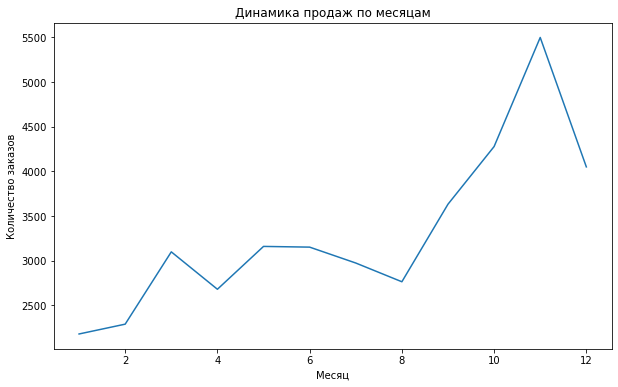

In [38]:
sales_cleaned['month'] = sales_cleaned['InvoiceDate'].dt.month

orders_per_month = sales_cleaned.groupby('month')['Invoice'].nunique()

orders_per_month.plot(kind = 'line',
                      title ='Динамика продаж по месяцам',
                      rot = 0, 
                      ylabel = 'Количество заказов', 
                      xlabel = 'Месяц',
                      figsize=(10, 6))
plt.show()

Наблюдаем ярко выраженную сезонность спроса - он стабильно растет, начиная с августа, и достигает своего пика в ноябре - около 5500 заказов. После чего в декабре резко снижается до 4000 заказов, к январю опускается до минимальных отметок и вплоть до февраля показывает слабую положительную динамику. Тенденция вполне логична и объясняется склонностью людей покупать новогодние подарки осенью (чаще всего в ноябре). В начале года обычно потребность в покупках/подарках снижается, а желание сэкономить, напротив, возрастает. Небольшой всплеск заказов фиксируется в марте, что может быть связано с празднованием 8 марта в ряде стран мира.
В летний период количество заказов колеблется от 3000 до 3200 и в целом характеризуется стабильностью.

## ABC-анализ

Посмотрим, какую выручку приносит каждый товар (SKU), затем отсортируем товары от максимальной выручки к минимальной и рассчитаем долю каждого SKU в общей выручке и накопительную долю.

In [39]:
sku_grouped = sales_cleaned.groupby('StockCode')['revenue'].sum().sort_values(ascending = False)
sku_grouped.head(20)

StockCode
22423    330284
DOT      309836
85123A   257725
85099B   180478
23843    168470
47566    148300
84879    129324
POST     125664
22086    117760
23166     81701
79321     80541
22197     79495
22386     76190
84347     71289
20725     71081
85099F    67966
48138     66954
23084     66862
20685     65488
21137     65189
Name: revenue, dtype: float64

In [40]:
sku_shares = (sku_grouped / sku_grouped.sum()) * 100
sku_shares = sku_shares.round(2)
print(f'Доля каждого SKU в общей выручке, %: {sku_shares}')

Доля каждого SKU в общей выручке, %: StockCode
22423    2 
DOT      2 
85123A   1 
85099B   1 
23843    1 
         ..
20721    0 
51014c   0 
84205C   0 
35930    0 
PADS     0 
Name: revenue, Length: 4912, dtype: float64


Посчитаем накопительную долю.

In [41]:
cumulative_share = sku_shares.cumsum()

sku_summary = pd.DataFrame({
    'revenue': sku_grouped,
    'share': sku_shares,
    'cumshare': cumulative_share
})

sku_summary.head(30)

,revenue,share,cumshare
StockCode,,,
22423,330284,2,2
DOT,309836,2,3
85123A,257725,1,4
85099B,180478,1,5
23843,168470,1,6
47566,148300,1,7
84879,129324,1,8
POST,125664,1,8
22086,117760,1,9


Присвоим каждому SKU категорию A, B или C в зависимости от накопительной доли выручки (где A – товары, которые формируют примерно первые 80% выручки; B – следующие примерно 15%; C – оставшаяся часть).

In [42]:
def abc_class(cum):
    if cum <= 80:
        return 'A'
    elif cum <= 95:
        return 'B'
    else:
        return 'C'

abc = pd.DataFrame({
    'revenue': sku_grouped,
    'share': sku_shares,
    'cumshare': cumulative_share,
})
abc['abc_category'] = abc['cumshare'].apply(abc_class)

Выведем количество и долю SKU в категориях A, B и C, а также их вклад в выручку.

In [43]:
pd.set_option('display.float_format', '{:.0f}'.format)

summary = abc.groupby('abc_category').agg(
    sku_count=('revenue', 'size'),
    total_revenue=('revenue', 'sum'),
).reindex(['A', 'B', 'C'])

total_skus = summary['sku_count'].sum()
total_rev = summary['total_revenue'].sum()    

summary['sku_share_%'] = (summary['sku_count'] / total_skus * 100).round(1)
summary['revenue_share_%'] = (summary['total_revenue'] / total_rev * 100).round(1)

summary

,sku_count,total_revenue,sku_share_%,revenue_share_%
abc_category,,,,
A,1025,16103733,21,80
B,1188,2888139,24,14
C,2699,1126093,55,6


Получившаяся таблица подтверждает принцип Парето: 21% товаров создали 80% общей выручки.
Покажем, топ-5 SKU из каждой категории.

In [44]:
abc_df = abc.reset_index()  

for cat in ['A', 'B', 'C']:
    top_skus = abc_df[abc_df['abc_category'] == cat].head(5)
    print(f"\n--- Категория {cat} (топ-5 SKU) ---")

    display(top_skus[['StockCode', 'revenue', 'share', 'cumshare']].style.format({
        'revenue': '{:,.0f}',
        'share': '{:.2f}%',
        'cumshare': '{:.2f}%'
    }))


--- Категория A (топ-5 SKU) ---


,StockCode,revenue,share,cumshare
0,22423,"330,284",1.64%,1.64%
1,DOT,"309,836",1.54%,3.18%
2,85123A,"257,725",1.28%,4.46%
3,85099B,"180,478",0.90%,5.36%
4,23843,"168,470",0.84%,6.20%



--- Категория B (топ-5 SKU) ---


,StockCode,revenue,share,cumshare
1025,22723,"4,263",0.02%,80.00%
1026,72802B,"4,259",0.02%,80.02%
1027,22530,"4,257",0.02%,80.04%
1028,20665,"4,256",0.02%,80.06%
1029,22312,"4,254",0.02%,80.08%



--- Категория C (топ-5 SKU) ---


,StockCode,revenue,share,cumshare
2213,84688,"1,314",0.01%,95.00%
2214,23373,"1,313",0.01%,95.01%
2215,35598D,"1,312",0.01%,95.02%
2216,23405,"1,311",0.01%,95.03%
2217,22481,"1,310",0.01%,95.04%


## XYZ-анализ

Для каждого StockCode сформируем временной ряд количества проданных единиц по месяцам. 

In [45]:
# Агрегируем продажи по SKU и месяцу (только где были продажи)
monthly_raw = (sales_cleaned.groupby(['StockCode', 'month'])['Quantity'].sum().reset_index(name='Qty_Month'))

# Строим полный календарь: все SKU × все месяцы
all_skus = monthly_raw['StockCode'].unique()
all_months = monthly_raw['month'].unique()

# Создаём полный индекс (все комбинации)
full_index = pd.MultiIndex.from_product([all_skus, all_months], names=['StockCode', 'month'])

# Переводим в DataFrame и присоединяем продажи
monthly_full = pd.DataFrame(index=full_index).reset_index()
monthly_full = monthly_full.merge(monthly_raw, on=['StockCode', 'month'], how='left')

# Заполняем отсутствующие продажи нулями
monthly_full['Qty_Month'] = monthly_full['Qty_Month'].fillna(0)

# Теперь в monthly_full есть 0 для всех месяцев, когда товар не продавался
display(monthly_full.head(10))


,StockCode,month,Qty_Month
0,10002,1,631
1,10002,2,309
2,10002,3,669
3,10002,4,1320
4,10002,5,1465
5,10002,6,463
6,10002,7,512
7,10002,8,586
8,10002,9,240
9,10002,10,1045


In [46]:
# Считаем среднее месячное количество, стандартное отклонение и коэффициент вариации CV = std / mean (с учётом нулей)
sku_stats = (
    monthly_full.groupby('StockCode')['Qty_Month']
    .agg(
        mean_qty='mean',
        std_qty='std',
        count_months='count'       
    )
    .reset_index()
)

In [47]:
# Коэффициент вариации: CV = std / mean

sku_stats['cv'] = np.where(
    sku_stats['mean_qty'] > 0,
    sku_stats['std_qty'] / sku_stats['mean_qty'],
    np.nan
)

Присвоим каждому SKU категорию X, Y, Z в зависимости от коэффициента вариации CV (где X – CV ≤ 0,5; Y – 0,5 < CV ≤ 1; Z – CV > 1).

In [48]:
def xyz_class(cv):
    if pd.isna(cv):
        return None
    if cv <= 0.10:
        return 'X'
    elif cv <= 0.25:
        return 'Y'
    else:
        return 'Z'

sku_stats['xyz_category'] = sku_stats['cv'].apply(xyz_class)

sku_stats

,StockCode,mean_qty,std_qty,count_months,cv,xyz_category
0,10002,722,391,12,1,Z
1,10002R,0,1,12,3,Z
2,10080,26,34,12,1,Z
3,10109,0,1,12,3,Z
4,10120,55,44,12,1,Z
...,...,...,...,...,...,...
4907,gift_0001_30,2,1,12,1,Z
4908,gift_0001_40,0,1,12,1,Z
4909,gift_0001_50,0,1,12,2,Z
4910,gift_0001_70,0,0,12,3,Z


## Объединенная матрица ABC/XYZ

Соединим результаты двух анализов по StockCode так, чтобы каждый товар получил одну из девяти комбинаций: AX, AY, AZ, BX, BY, BZ, CX, CY или CZ.

In [49]:
abc_df = abc.reset_index()
combined_matrix = pd.merge(abc_df, sku_stats, on='StockCode', how='left')
combined_matrix

,StockCode,revenue,share,cumshare,abc_category,mean_qty,std_qty,count_months,cv,xyz_category
0,22423,330284,2,2,A,2206,744,12,0,Z
1,DOT,309836,2,3,A,118,19,12,0,Y
2,85123A,257725,1,4,A,7850,2168,12,0,Z
3,85099B,180478,1,5,A,8061,2090,12,0,Z
4,23843,168470,1,6,A,6750,23381,12,3,Z
...,...,...,...,...,...,...,...,...,...,...
4907,20721,1,0,98,C,0,0,12,3,Z
4908,51014c,1,0,98,C,0,0,12,3,Z
4909,84205C,0,0,98,C,0,1,12,3,Z
4910,35930,0,0,98,C,0,0,12,3,Z


Для каждой группы рассчитаем количество SKU, долю ассортимента, выручку и ее долю, количество проданных единиц и количество заказов. 
Также добавим число покупателей, количество активных месяцев и среднюю цену.

In [50]:
# Делаем словари (какой SKU к какой категории относится)
abc_dict = combined_matrix.set_index('StockCode')['abc_category'].to_dict()
xyz_dict = combined_matrix.set_index('StockCode')['xyz_category'].to_dict()

# Добавляем категории в таблицу продаж 
sales_cleaned['ABC'] = sales_cleaned['StockCode'].map(abc_dict)
sales_cleaned['XYZ'] = sales_cleaned['StockCode'].map(xyz_dict)

# Считаем показатели по каждой группе ABC/XYZ 
grouped = sales_cleaned.groupby(['ABC', 'XYZ'])

stats = grouped.agg(
    sku_count=('StockCode', 'nunique'),      
    total_revenue=('revenue', 'sum'),      
    total_qty=('Quantity', 'sum'),           
    order_count=('Invoice', 'nunique'),    
    customer_count=('CustomerID', 'nunique') 
).reset_index()

# Считаем доли 
total_skus = stats['sku_count'].sum()
total_rev = stats['total_revenue'].sum()

stats['sku_share_%'] = (stats['sku_count'] / total_skus * 100).round(1)
stats['revenue_share_%'] = (stats['total_revenue'] / total_rev * 100).round(1)

# Считаем активные месяцы 

sales_cleaned['Month'] = sales_cleaned['InvoiceDate'].dt.to_period('M')

active_months = (
    sales_cleaned
    .groupby(['ABC', 'XYZ'])['Month']
    .nunique() 
    .reset_index(name='active_months')
)

# Присоединяем активные месяцы к нашей таблице
stats = stats.merge(active_months, on=['ABC', 'XYZ'])

# Средняя цена 
stats['avg_price'] = (stats['total_revenue'] / stats['total_qty']).round(2)

display(stats)

,ABC,XYZ,sku_count,total_revenue,total_qty,order_count,customer_count,sku_share_%,revenue_share_%,active_months,avg_price
0,A,Y,38,1168449,649906,17971,3890,1,6,25,2
1,A,Z,987,14935284,7075362,38247,5800,20,74,25,2
2,B,Y,6,18332,38368,2067,749,0,0,25,0
3,B,Z,1182,2869807,2247143,29877,5425,24,14,25,1
4,C,Y,1,1166,2815,102,93,0,0,24,0
5,C,Z,2698,1124926,1180097,20360,4581,55,6,25,1


## Интерпретация и стратегия управления

Видим, что сформировалось 6 комбинаций товаров: AY, AZ, BY, BZ, CY и CZ.
Предложим стратегию по управлению данными группами.

In [51]:
strategies = pd.DataFrame({
    'Группа': ['AY', 'AZ', 'BY', 'BZ', 'CY', 'CZ'],
    'Характеристика': [
        'Высокая выручка, умеренная нестабильность',
        'Высокая выручка, высокая нестабильность',
        'Средняя выручка, умеренная нестабильность',
        'Средняя выручка, высокая нестабильность',
        'Низкая выручка, умеренная нестабильность',
        'Низкая выручка, высокая нестабильность'
    ],
    'Основная стратегия': [
        'Удержание и контроль',
        'Жёсткий мониторинг',
        'Оптимизация',
        'Осторожность',
        'Минимизация затрат',
        'Кандидаты на вывод'
    ],
    'Ключевые действия': [
        'Запас с поправкой на колебания; пересмотр прогноза 1 раз в 1–2 недели',
        'Короткие партии; гибкие поставки; повышенный запас; еженедельный пересмотр прогноза',
        'Стандартные поставки; средний запас; ежемесячный пересмотр прогноза',
        'Уменьшение партий; рассмотреть схему “заказ под клиента”; выделить сезонность',
        'Минимальный запас; сокращение частоты заказов; пересмотр раз в квартал',
        'Минимальный запас или “под заказ”; постепенно готовить к выводу из ассортимента'
    ],
    'Приоритет управления': [
        'Высокий',
        'Критический',
        'Средний',
        'Ниже среднего',
        'Низкий',
        'Минимальный'
    ]
})

pd.set_option('display.max_colwidth', None)

strategies

,Группа,Характеристика,Основная стратегия,Ключевые действия,Приоритет управления
0,AY,"Высокая выручка, умеренная нестабильность",Удержание и контроль,Запас с поправкой на колебания; пересмотр прогноза 1 раз в 1–2 недели,Высокий
1,AZ,"Высокая выручка, высокая нестабильность",Жёсткий мониторинг,Короткие партии; гибкие поставки; повышенный запас; еженедельный пересмотр прогноза,Критический
2,BY,"Средняя выручка, умеренная нестабильность",Оптимизация,Стандартные поставки; средний запас; ежемесячный пересмотр прогноза,Средний
3,BZ,"Средняя выручка, высокая нестабильность",Осторожность,Уменьшение партий; рассмотреть схему “заказ под клиента”; выделить сезонность,Ниже среднего
4,CY,"Низкая выручка, умеренная нестабильность",Минимизация затрат,Минимальный запас; сокращение частоты заказов; пересмотр раз в квартал,Низкий
5,CZ,"Низкая выручка, высокая нестабильность",Кандидаты на вывод,Минимальный запас или “под заказ”; постепенно готовить к выводу из ассортимента,Минимальный


## Формируем список кандидатов на сокращение

Сформируем критерии отбора для сокращения ассортимента товаров.
Предлагаемые критерии:

1. Низкий вклад в выручку (менее 0,5%)
2. Очень сильная нестабильность спроса (CV > 2), в том числе наличие нулевых продаж в месяце
3. Малое количество уникальных заказов (менее 300)
4. Малое количество уникальных клиентов (менее 300)

По данным критериям выделим те SKU, которые попадают под сокращение.

In [52]:
# Считаем недостающие метрики

# Считаем заказы по SKU (без merge — сразу как словарь)
orders_map = sales_cleaned.groupby('StockCode')['Invoice'].nunique()

# Считаем клиентов по SKU
customers_map = sales_cleaned.groupby('StockCode')['CustomerID'].nunique()

# Считаем суммарное количество по SKU и месяцу
monthly_qty = sales_cleaned.groupby(['StockCode', 'month'])['Quantity'].sum()
# Находим, где нулевые продажи 
zero_months_mask = monthly_qty == 0
# Для каждого SKU считаем, сколько таких месяцев
zero_months_map = zero_months_mask.groupby(level='StockCode').sum()

# Подставляем значения по StockCode
combined_matrix['orders_count'] = combined_matrix['StockCode'].map(orders_map).fillna(0).astype(int)
combined_matrix['customers_count'] = combined_matrix['StockCode'].map(customers_map).fillna(0).astype(int)
combined_matrix['zero_sales_months'] = combined_matrix['StockCode'].map(zero_months_map).fillna(0).astype(int)

# Флаг: были ли вообще нулевые месяцы
combined_matrix['has_zero_sales'] = combined_matrix['zero_sales_months'] > 0

# Формируем комбинации ABC/XYZ
combined_matrix['abc_xyz'] = combined_matrix['abc_category'] + combined_matrix['xyz_category']

combined_matrix.head()    

,StockCode,revenue,share,cumshare,abc_category,mean_qty,std_qty,count_months,cv,xyz_category,orders_count,customers_count,zero_sales_months,has_zero_sales,abc_xyz
0,22423,330284,2,2,A,2206,744,12,0,Z,3907,1314,0,False,AZ
1,DOT,309836,2,3,A,118,19,12,0,Y,1414,1,0,False,AY
2,85123A,257725,1,4,A,7850,2168,12,0,Z,5365,1490,0,False,AZ
3,85099B,180478,1,5,A,8061,2090,12,0,Z,3976,978,0,False,AZ
4,23843,168470,1,6,A,6750,23381,12,3,Z,1,1,0,False,AZ


Применяем данные критерии к SKU, чтобы выявить кандидатов на вывод из ассортимента.

In [53]:
# Флаг: вклад в выручку < 0.5%

combined_matrix['flag_low_revenue'] = combined_matrix['share'] < 0.5

# Флаг: нестабильный спрос — cv> 2 ИЛИ были нулевые месяцы
cv_threshold = 2
combined_matrix['flag_unstable'] = (combined_matrix['cv'] > cv_threshold)|combined_matrix['has_zero_sales']

# Флаг: менее 300 уникальных заказов
combined_matrix['flag_low_orders'] = combined_matrix['orders_count'] < 300

# Флаг: менее 300 уникальных клиентов
combined_matrix['flag_low_clients'] = combined_matrix['customers_count'] < 300

# Кандидат на вывод: выполняются ВСЕ 4 критерия одновременно
combined_matrix['candidate_drop'] = (
    combined_matrix['flag_low_revenue'] &
    combined_matrix['flag_unstable'] &
    combined_matrix['flag_low_orders'] &
    combined_matrix['flag_low_clients']
)

# Считаем итоги
total_skus = len(combined_matrix)
drop_candidates = combined_matrix['candidate_drop'].sum()
drop_revenue_share = combined_matrix.loc[combined_matrix['candidate_drop'], 'share'].sum()

print(f"Всего SKU: {total_skus}")
print(f"Кандидатов на вывод: {drop_candidates} ({drop_candidates/total_skus:.2%} от ассортимента)")
print(f"Их доля в выручке: {drop_revenue_share:.2f}%")

Всего SKU: 4912
Кандидатов на вывод: 1039 (21.15% от ассортимента)
Их доля в выручке: 3.17%


Таким образом, предлагается проверить 21,15% товаров, на них приходится 3,17% исторической выручки.